In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Creating a nonlinear relation data
X = 6 * np.random.rand(100,1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100,1)
## y is a quardratic equation y=0.5x^2 + 1.5x + outliers

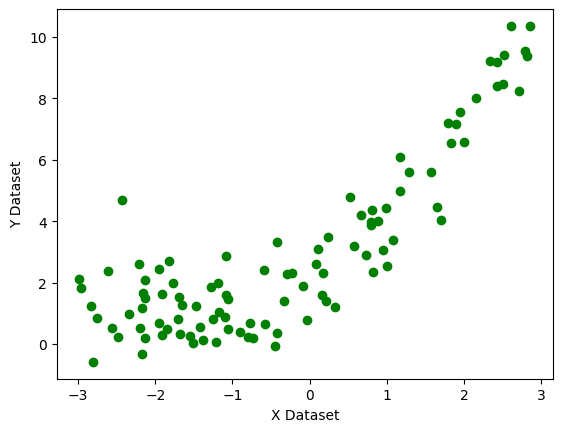

In [5]:
plt.scatter(X,y,c='g')
plt.xlabel('X Dataset')
plt.ylabel('Y Dataset')
plt.show()

In [35]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [36]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()

In [37]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
y_predict  =regression.predict(X_test)
y_predict

array([[1.13422153],
       [1.88792521],
       [4.76431168],
       [0.96147067],
       [3.15771545],
       [5.85879949],
       [5.00410531],
       [2.9647161 ],
       [0.76942338],
       [1.74314057],
       [1.78573669],
       [2.01391868],
       [0.51153899],
       [4.41151652],
       [0.41380946],
       [2.98252934],
       [1.83590093],
       [0.01199037],
       [4.72499328],
       [2.42325286],
       [6.39148155],
       [6.22979846],
       [7.50259104],
       [5.0227763 ],
       [3.89744807]])

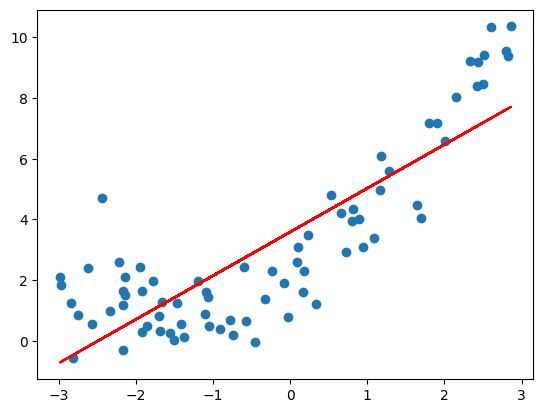

In [39]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),'r')
plt.show()

In [40]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error,r2_score

mse = mean_squared_error(y_test,y_predict)
rmse = root_mean_squared_error(y_test,y_predict)
r2 = r2_score(y_test,y_predict)
r2_adjusted = 1-(1-r2)*(len(y_test)-1)/(len(y_test)-1-1)

In [41]:
print(mse)
print(rmse)
print(r2)
print(r2_adjusted)

1.7673650119750601
1.3294228115896989
0.665903614544889
0.6513776847424929


In [42]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2,include_bias=True)

In [43]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
X_train_poly

array([[ 1.00000000e+00,  2.51920498e+00,  6.34639371e+00],
       [ 1.00000000e+00, -2.13599097e+00,  4.56245742e+00],
       [ 1.00000000e+00,  1.65062381e+00,  2.72455895e+00],
       [ 1.00000000e+00, -2.43613578e+00,  5.93475755e+00],
       [ 1.00000000e+00,  1.28579965e+00,  1.65328075e+00],
       [ 1.00000000e+00,  2.82374100e+00,  7.97351322e+00],
       [ 1.00000000e+00, -1.05188430e+00,  1.10646057e+00],
       [ 1.00000000e+00, -2.16085340e+00,  4.66928742e+00],
       [ 1.00000000e+00, -4.54602131e-01,  2.06663098e-01],
       [ 1.00000000e+00, -2.83688324e+00,  8.04790655e+00],
       [ 1.00000000e+00, -2.96782606e+00,  8.80799151e+00],
       [ 1.00000000e+00,  2.32363244e-01,  5.39926774e-02],
       [ 1.00000000e+00, -5.72535011e-01,  3.27796339e-01],
       [ 1.00000000e+00,  2.33838382e+00,  5.46803887e+00],
       [ 1.00000000e+00, -1.47130490e+00,  2.16473811e+00],
       [ 1.00000000e+00,  2.86078332e+00,  8.18408119e+00],
       [ 1.00000000e+00,  2.42908057e+00

In [45]:
regression2 = LinearRegression()
regression2.fit(X_train_poly,y_train)
y_predict_poly = regression2.predict(X_test_poly)

In [ ]:
# R2 Score of the model
score = r2_score(y_test,y_predict_poly)
score

0.8103598105419513

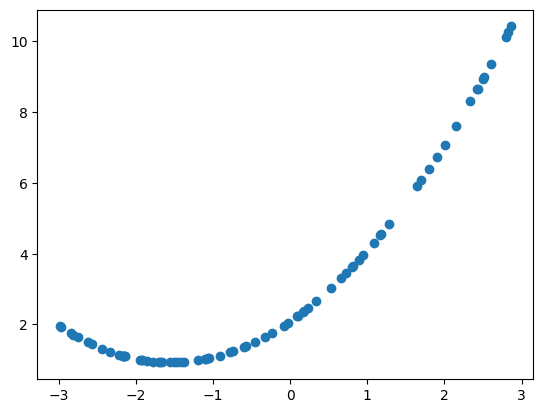

In [ ]:
#Polynomial Regression Best Fit Line Plot
plt.scatter(X_train,regression2.predict(X_train_poly))
plt.show()